<a href="https://colab.research.google.com/github/fralfaro/MA_M3/blob/main/semana_02/sc_01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Numpy



<img src="https://upload.wikimedia.org/wikipedia/commons/thumb/3/31/NumPy_logo_2020.svg/960px-NumPy_logo_2020.svg.png?utm_source=commons.wikimedia.org&utm_campaign=index&utm_content=thumbnail&_=20251223090330" width = "300" align="center"/>

> *"NumPy es al cómputo científico en Python lo que el álgebra lineal
> es a las matemáticas: el lenguaje base sobre el que todo lo demás se construye."*


## Introducción

[NumPy](https://numpy.org/) es la biblioteca fundamental para el cómputo numérico en Python. Su objeto central — el **array multidimensional** (`ndarray`) —  permite operar sobre vectores y matrices de forma eficiente, con una sintaxis mucho más limpia que las listas nativas de Python.

En este módulo aprenderás a:

- Crear y manipular arrays de una y múltiples dimensiones
- Realizar operaciones aritméticas, estadísticas y de álgebra lineal
- Visualizar datos numéricos con **matplotlib** de forma básica


## Python Lists vs Numpy Arrays

Antes de crear arrays, vale la pena entender por qué no basta con las listas de Python.



```python
64 + 8 * len (lst) + + len (lst) * 28
```                   

<img src="https://raw.githubusercontent.com/fralfaro/MAT281_2022/main/docs/lectures/data_manipulation/scientific_computing/images/list_structure.png" width = "500" align="center"/>

> Listas


```python
96 + n * 8 bytes
```

<img src="https://raw.githubusercontent.com/fralfaro/MAT281_2022/main/docs/lectures/data_manipulation/scientific_computing/images/array_structure.png" width = "500" align="center"/>

> Numpy arrays

In [1]:
import numpy as np 
import time
import sys

def arreglo_python(n):
    t1 = time.time()
    X = range(n)
    Y = range(n)
    Z = [X[i] + Y[i] for i in range(len(X)) ]
    return (time.time() - t1,sys.getsizeof(Z) )

def arreglo_numpy(n):
    t1 = time.time()
    X = np.arange(n)
    Y = np.arange(n)
    Z = X + Y
    return (time.time() - t1,sys.getsizeof(Z) )

In [2]:
# generar varios casos
for size_of_vec in [10,100,1000,10000,100000,1000000]:
    print(f"size of vector: {size_of_vec}")
    
    #list vs numpy
    t1, size1 = arreglo_python(size_of_vec)
    t2, size2 = arreglo_numpy(size_of_vec)
    
    # resultados
    print(f"python list -- time: {round(t1,8)} seg, size: {size1} bytes")
    print(f"numpy array -- time: {round(t2,8)} seg, size: {size2} bytes\n")

size of vector: 10
python list -- time: 2.15e-06 seg, size: 184 bytes
numpy array -- time: 0.00015211 seg, size: 192 bytes

size of vector: 100
python list -- time: 4.77e-06 seg, size: 920 bytes
numpy array -- time: 4.29e-06 seg, size: 912 bytes

size of vector: 1000
python list -- time: 5.293e-05 seg, size: 8856 bytes
numpy array -- time: 2.909e-05 seg, size: 8112 bytes

size of vector: 10000
python list -- time: 0.00060391 seg, size: 85176 bytes
numpy array -- time: 7.82e-05 seg, size: 80112 bytes

size of vector: 100000
python list -- time: 0.00564814 seg, size: 800984 bytes
numpy array -- time: 0.00017524 seg, size: 800112 bytes

size of vector: 1000000
python list -- time: 0.05759501 seg, size: 8448728 bytes
numpy array -- time: 0.00160193 seg, size: 8000112 bytes



> ✅ NumPy es ~2x más eficiente en memoria y hasta **50x más rápido**, para operaciones numéricas a gran escala.

## Objetos en Numpy

<img src="https://miro.medium.com/v2/resize:fit:1400/1*X0Dg7QfSYtWhSAu-afi8-g.png" width = "400" align="center"/>


El objeto principal es el `ndarray`. Puede ser 1D (vector), 2D (matriz) o nD (tensor).


In [3]:
import numpy as np

# Vector (1D)
v = np.array([1, 2, 3])

# Matriz (2D)
M = np.array([
    [1, 2, 3],
    [4, 5, 6]
])

# Tensor (3D)
T = np.array([
    [[1, 2], [3, 4]],
    [[5, 6], [7, 8]]
])

print(f"vector: shape={v.shape}, ndim={v.ndim}, dtype={v.dtype}")
print(f"matriz: shape={M.shape}, ndim={M.ndim}, dtype={M.dtype}")
print(f"tensor: shape={T.shape}, ndim={T.ndim}, dtype={T.dtype}")

vector: shape=(3,), ndim=1, dtype=int64
matriz: shape=(2, 3), ndim=2, dtype=int64
tensor: shape=(2, 2, 2), ndim=3, dtype=int64


| Atributo     | Descripción                              | Ejemplo         |
|--------------|------------------------------------------|-----------------|
| `.shape`     | Dimensiones del array                    | `(3,)`, `(2,3)` |
| `.ndim`      | Número de dimensiones                    | `1`, `2`, `3`   |
| `.size`      | Total de elementos                       | `6`             |
| `.dtype`     | Tipo de datos                            | `int64`, `float64` |

### Arrays especiales


In [4]:
import numpy as np

print("zeros (3x3):")
print(np.zeros((3, 3)))

print("\nones (2x4):")
print(np.ones((2, 4)))

print("\nidentidad (3x3):")
print(np.eye(3))

print("\narange (0 a 10, paso 2):")
print(np.arange(0, 10, 2))

print("\nlinspace (0 a 1, 5 puntos):")
print(np.linspace(0, 1, 5))

np.random.seed(42)
print("\nuniform aleatorio (seed=42):")
print(np.random.uniform(0, 10, size=6))

zeros (3x3):
[[0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]]

ones (2x4):
[[1. 1. 1. 1.]
 [1. 1. 1. 1.]]

identidad (3x3):
[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]

arange (0 a 10, paso 2):
[0 2 4 6 8]

linspace (0 a 1, 5 puntos):
[0.   0.25 0.5  0.75 1.  ]

uniform aleatorio (seed=42):
[3.74540119 9.50714306 7.31993942 5.98658484 1.5601864  1.5599452 ]


## Vectores

### Definición

Un **vector** de dimensión $n$ es una lista ordenada de $n$ números reales. El conjunto de todos ellos se denota $\mathbb{R}^n$:

$$
\mathbf{v} \;=\;
\begin{bmatrix} v_1 \\ v_2 \\ \vdots \\ v_n \end{bmatrix} \in \mathbb{R}^{n},
\qquad v_i \in \mathbb{R}
$$

- $v_i$ es la **componente** $i$-ésima del vector.
- Por convención, un vector es un **vector columna** (orden $n \times 1$).
- Su transpuesta $\mathbf{v}^{T} = [\,v_1\; v_2\; \cdots\; v_n\,]$ es un **vector fila** (orden $1 \times n$).

> ⚠️ En NumPy un vector 1D tiene `shape = (n,)`: **no es fila ni columna**, es simplemente un arreglo de $n$ elementos. Cuando la distinción importa (por ejemplo, en un producto matricial) hay que forzar la forma con `reshape`.

In [5]:
import numpy as np

v = np.array([1, 2, 3])          # vector "plano" de NumPy

columna = v.reshape(-1, 1)       # 3 x 1  -> vector columna matemático
fila = v.reshape(1, -1)          # 1 x 3  -> vector fila matemático

print(f"v        -> shape={v.shape}       ndim={v.ndim}")
print(v)
print(f"\ncolumna  -> shape={columna.shape}    ndim={columna.ndim}")
print(columna)
print(f"\nfila     -> shape={fila.shape}    ndim={fila.ndim}")
print(fila)

# componentes: la matematica indexa desde 1, NumPy desde 0
print(f"\nv_1 = {v[0]},  v_2 = {v[1]},  v_3 = {v[2]}")
print(f"dimension n = {v.size}")

v        -> shape=(3,)       ndim=1
[1 2 3]

columna  -> shape=(3, 1)    ndim=2
[[1]
 [2]
 [3]]

fila     -> shape=(1, 3)    ndim=2
[[1 2 3]]

v_1 = 1,  v_2 = 2,  v_3 = 3
dimension n = 3


### Suma y producto por escalar

Dados $\mathbf{u}, \mathbf{v} \in \mathbb{R}^n$ y $\alpha \in \mathbb{R}$, ambas operaciones se definen **componente a componente**:

$$
(\mathbf{u} + \mathbf{v})_i = u_i + v_i
\qquad\qquad
(\alpha\,\mathbf{v})_i = \alpha\, v_i
$$

Con estas dos operaciones $\mathbb{R}^n$ es un **espacio vectorial**, es decir, se cumplen:

| Propiedad | Expresión |
|---|---|
| Conmutatividad | $\mathbf{u} + \mathbf{v} = \mathbf{v} + \mathbf{u}$ |
| Asociatividad | $(\mathbf{u} + \mathbf{v}) + \mathbf{w} = \mathbf{u} + (\mathbf{v} + \mathbf{w})$ |
| Elemento neutro | $\mathbf{v} + \mathbf{0} = \mathbf{v}$ |
| Elemento opuesto | $\mathbf{v} + (-\mathbf{v}) = \mathbf{0}$ |
| Distributividad sobre vectores | $\alpha(\mathbf{u} + \mathbf{v}) = \alpha\mathbf{u} + \alpha\mathbf{v}$ |
| Distributividad sobre escalares | $(\alpha + \beta)\,\mathbf{v} = \alpha\mathbf{v} + \beta\mathbf{v}$ |
| Asociatividad de escalares | $\alpha(\beta \mathbf{v}) = (\alpha\beta)\mathbf{v}$ |
| Neutro multiplicativo | $1 \cdot \mathbf{v} = \mathbf{v}$ |

Una **combinación lineal** de $\mathbf{v}_1,\dots,\mathbf{v}_k$ es cualquier vector de la forma $\alpha_1\mathbf{v}_1 + \cdots + \alpha_k\mathbf{v}_k$. Todo lo que se puede construir así es el **espacio generado** (*span*) por esos vectores.

In [6]:
import numpy as np

u = np.array([1., 2., 3.])
w = np.array([4., 5., 6.])
z = np.array([-1., 0., 2.])
alpha, beta = 2.0, -3.0

print(f"u + w        = {u + w}")
print(f"u - w        = {u - w}")
print(f"{alpha} * u      = {alpha * u}")
print(f"combinacion lineal {alpha}u + {beta}w = {alpha * u + beta * w}")

# --- verificacion numerica de las propiedades ---
print("\n--- propiedades del espacio vectorial ---")
print(f"conmutativa      u+w == w+u            : {np.allclose(u + w, w + u)}")
print(f"asociativa       (u+w)+z == u+(w+z)    : {np.allclose((u + w) + z, u + (w + z))}")
print(f"neutro           u+0 == u              : {np.allclose(u + np.zeros(3), u)}")
print(f"opuesto          u+(-u) == 0           : {np.allclose(u + (-u), np.zeros(3))}")
print(f"distributiva 1   a(u+w) == au+aw       : {np.allclose(alpha * (u + w), alpha * u + alpha * w)}")
print(f"distributiva 2   (a+b)u == au+bu       : {np.allclose((alpha + beta) * u, alpha * u + beta * u)}")
print(f"asociativa esc.  a(bu) == (ab)u        : {np.allclose(alpha * (beta * u), (alpha * beta) * u)}")

u + w        = [5. 7. 9.]
u - w        = [-3. -3. -3.]
2.0 * u      = [2. 4. 6.]
combinacion lineal 2.0u + -3.0w = [-10. -11. -12.]

--- propiedades del espacio vectorial ---
conmutativa      u+w == w+u            : True
asociativa       (u+w)+z == u+(w+z)    : True
neutro           u+0 == u              : True
opuesto          u+(-u) == 0           : True
distributiva 1   a(u+w) == au+aw       : True
distributiva 2   (a+b)u == au+bu       : True
asociativa esc.  a(bu) == (ab)u        : True


### Producto punto y norma

El **producto punto** (o producto interno) de $\mathbf{u}, \mathbf{v} \in \mathbb{R}^n$ es un **escalar**:

$$
\mathbf{u} \cdot \mathbf{v} \;=\; \mathbf{u}^{T}\mathbf{v} \;=\; \sum_{i=1}^{n} u_i\, v_i
$$

A partir de él se define la **norma euclidiana** (el "largo" del vector):

$$
\|\mathbf{v}\|_2 \;=\; \sqrt{\mathbf{v}\cdot\mathbf{v}} \;=\; \sqrt{\sum_{i=1}^{n} v_i^{2}}
$$

que es un caso particular de la **norma $p$**:

$$
\|\mathbf{v}\|_p = \Big(\sum_{i=1}^{n} |v_i|^{p}\Big)^{1/p},
\qquad
\|\mathbf{v}\|_1 = \sum_{i} |v_i|,
\qquad
\|\mathbf{v}\|_\infty = \max_i |v_i|
$$

**Propiedades:**

| Propiedad | Expresión |
|---|---|
| Conmutatividad | $\mathbf{u}\cdot\mathbf{v} = \mathbf{v}\cdot\mathbf{u}$ |
| Distributividad | $\mathbf{u}\cdot(\mathbf{v}+\mathbf{w}) = \mathbf{u}\cdot\mathbf{v} + \mathbf{u}\cdot\mathbf{w}$ |
| Homogeneidad | $(\alpha\mathbf{u})\cdot\mathbf{v} = \alpha\,(\mathbf{u}\cdot\mathbf{v})$ |
| Positividad | $\mathbf{v}\cdot\mathbf{v} \ge 0$, con igualdad sólo si $\mathbf{v}=\mathbf{0}$ |
| Cauchy–Schwarz | $\lvert\mathbf{u}\cdot\mathbf{v}\rvert \;\le\; \|\mathbf{u}\|\,\|\mathbf{v}\|$ |
| Desigualdad triangular | $\|\mathbf{u}+\mathbf{v}\| \;\le\; \|\mathbf{u}\| + \|\mathbf{v}\|$ |
| Homogeneidad de la norma | $\|\alpha\mathbf{v}\| = \lvert\alpha\rvert\,\|\mathbf{v}\|$ |

> ⚠️ **Cuidado con la notación:** en NumPy `u * v` es el producto **elemento a elemento** (otro vector), mientras que `u @ v` o `np.dot(u, v)` es el producto **punto** (un escalar).

In [7]:
import numpy as np

u = np.array([1., 2., 3.])
v = np.array([4., 5., 6.])

print("--- producto punto vs elemento a elemento ---")
print(f"u * v   (elemento a elemento) = {u * v}")
print(f"u @ v   (producto punto)      = {u @ v}")
print(f"suma manual sum(u_i*v_i)      = {np.sum(u * v)}")
print(f"np.dot(u, v)                  = {np.dot(u, v)}")
print(f"np.inner(u, v)                = {np.inner(u, v)}")

print("\n--- normas de u ---")
print(f"||u||_1   (manhattan)  = {np.linalg.norm(u, 1):.4f}")
print(f"||u||_2   (euclidiana) = {np.linalg.norm(u):.4f}")
print(f"||u||_inf (maximo)     = {np.linalg.norm(u, np.inf):.4f}")
print(f"verificacion sqrt(u.u) = {np.sqrt(u @ u):.4f}")

print("\n--- propiedades ---")
w, alpha = np.array([-2., 7., 0.5]), 3.0
print(f"conmutativa     u.v == v.u             : {np.isclose(u @ v, v @ u)}")
print(f"distributiva    u.(v+w) == u.v + u.w   : {np.isclose(u @ (v + w), u @ v + u @ w)}")
print(f"homogeneidad    (au).v == a(u.v)       : {np.isclose((alpha * u) @ v, alpha * (u @ v))}")
print(f"norma homogenea ||au|| == |a| ||u||    : {np.isclose(np.linalg.norm(alpha * u), abs(alpha) * np.linalg.norm(u))}")

print("\n--- desigualdades ---")
cs_izq, cs_der = abs(u @ v), np.linalg.norm(u) * np.linalg.norm(v)
tr_izq = np.linalg.norm(u + v)
tr_der = np.linalg.norm(u) + np.linalg.norm(v)
print(f"Cauchy-Schwarz : |u.v| = {cs_izq:.4f}  <=  ||u|| ||v|| = {cs_der:.4f}   -> {cs_izq <= cs_der}")
print(f"Triangular     : ||u+v|| = {tr_izq:.4f} <= ||u||+||v|| = {tr_der:.4f}  -> {tr_izq <= tr_der}")

--- producto punto vs elemento a elemento ---
u * v   (elemento a elemento) = [ 4. 10. 18.]
u @ v   (producto punto)      = 32.0
suma manual sum(u_i*v_i)      = 32.0
np.dot(u, v)                  = 32.0
np.inner(u, v)                = 32.0

--- normas de u ---
||u||_1   (manhattan)  = 6.0000
||u||_2   (euclidiana) = 3.7417
||u||_inf (maximo)     = 3.0000
verificacion sqrt(u.u) = 3.7417

--- propiedades ---
conmutativa     u.v == v.u             : True
distributiva    u.(v+w) == u.v + u.w   : True
homogeneidad    (au).v == a(u.v)       : True
norma homogenea ||au|| == |a| ||u||    : True

--- desigualdades ---
Cauchy-Schwarz : |u.v| = 32.0000  <=  ||u|| ||v|| = 32.8329   -> True
Triangular     : ||u+v|| = 12.4499 <= ||u||+||v|| = 12.5166  -> True


### Ángulo, ortogonalidad y proyección

El producto punto codifica el **ángulo** $\theta$ entre dos vectores no nulos:

$$
\mathbf{u}\cdot\mathbf{v} = \|\mathbf{u}\|\,\|\mathbf{v}\|\cos\theta
\qquad\Longleftrightarrow\qquad
\cos\theta = \frac{\mathbf{u}\cdot\mathbf{v}}{\|\mathbf{u}\|\,\|\mathbf{v}\|}
$$

| Signo de $\mathbf{u}\cdot\mathbf{v}$ | Ángulo | Interpretación |
|---|---|---|
| $> 0$ | $\theta < 90^\circ$ | apuntan hacia el mismo lado |
| $= 0$ | $\theta = 90^\circ$ | **ortogonales**: $\mathbf{u} \perp \mathbf{v}$ |
| $< 0$ | $\theta > 90^\circ$ | apuntan en sentidos opuestos |

El **vector unitario** en la dirección de $\mathbf{v}$ (normalización) y la **proyección ortogonal** de $\mathbf{u}$ sobre $\mathbf{v}$ son:

$$
\hat{\mathbf{v}} = \frac{\mathbf{v}}{\|\mathbf{v}\|}
\qquad\qquad
\operatorname{proj}_{\mathbf{v}}(\mathbf{u}) = \frac{\mathbf{u}\cdot\mathbf{v}}{\mathbf{v}\cdot\mathbf{v}}\;\mathbf{v}
$$

El residuo $\mathbf{r} = \mathbf{u} - \operatorname{proj}_{\mathbf{v}}(\mathbf{u})$ siempre es ortogonal a $\mathbf{v}$, y se cumple el **teorema de Pitágoras**:

$$
\mathbf{u} \perp \mathbf{v} \;\Longrightarrow\; \|\mathbf{u}+\mathbf{v}\|^{2} = \|\mathbf{u}\|^{2} + \|\mathbf{v}\|^{2}
$$

> 📌 El $\cos\theta$ se conoce en ciencia de datos como **similitud coseno**, y es la métrica estándar para comparar documentos, *embeddings* y perfiles de usuario. La proyección es, además, la idea central detrás de la **regresión lineal**.

In [8]:
import numpy as np

def angulo(u, v, grados=True):
    """Angulo entre dos vectores via producto punto."""
    cos = (u @ v) / (np.linalg.norm(u) * np.linalg.norm(v))
    cos = np.clip(cos, -1.0, 1.0)          # protege contra errores de redondeo
    theta = np.arccos(cos)
    return np.degrees(theta) if grados else theta

pares = {
    "mismo sentido":  (np.array([1., 0.]), np.array([3., 0.])),
    "45 grados":      (np.array([1., 0.]), np.array([1., 1.])),
    "ortogonales":    (np.array([1., 0.]), np.array([0., 5.])),
    "opuestos":       (np.array([1., 2.]), np.array([-1., -2.])),
}

print(f"{'caso':<16}{'u.v':>10}{'cos(theta)':>14}{'angulo':>12}")
for nombre, (a, b) in pares.items():
    cos = (a @ b) / (np.linalg.norm(a) * np.linalg.norm(b))
    print(f"{nombre:<16}{a @ b:>10.2f}{cos:>14.4f}{angulo(a, b):>11.2f}")

# --- normalizacion ---
v = np.array([3., 4.])
v_hat = v / np.linalg.norm(v)
print(f"\nv = {v},  ||v|| = {np.linalg.norm(v):.2f}")
print(f"v_hat = {v_hat},  ||v_hat|| = {np.linalg.norm(v_hat):.2f}  (unitario)")

# --- ortogonalidad y Pitagoras ---
e1, e2 = np.array([1., 0.]), np.array([0., 1.])
print(f"\ne1.e2 = {e1 @ e2:.1f}  -> ortogonales")
print(f"||e1+e2||^2 = {np.linalg.norm(e1 + e2) ** 2:.4f}"
      f"   ||e1||^2 + ||e2||^2 = {np.linalg.norm(e1) ** 2 + np.linalg.norm(e2) ** 2:.4f}  (Pitagoras)")

caso                   u.v    cos(theta)      angulo
mismo sentido         3.00        1.0000       0.00
45 grados             1.00        0.7071      45.00
ortogonales           0.00        0.0000      90.00
opuestos             -5.00       -1.0000     180.00

v = [3. 4.],  ||v|| = 5.00
v_hat = [0.6 0.8],  ||v_hat|| = 1.00  (unitario)

e1.e2 = 0.0  -> ortogonales
||e1+e2||^2 = 2.0000   ||e1||^2 + ||e2||^2 = 2.0000  (Pitagoras)


In [9]:
import numpy as np
import matplotlib.pyplot as plt

u = np.array([3.0, 4.0])
v = np.array([6.0, 1.0])

p = (u @ v) / (v @ v) * v      # proyeccion de u sobre v
r = u - p                      # residuo (componente ortogonal)

print(f"proj_v(u) = {np.round(p, 4)}")
print(f"residuo r = {np.round(r, 4)}")
print(f"r . v     = {r @ v:.10f}   -> el residuo es ortogonal a v")
print(f"||u||^2 = {u @ u:.4f}  ==  ||p||^2 + ||r||^2 = {p @ p + r @ r:.4f}   (Pitagoras)")
print(f"angulo(u, v) = {np.degrees(np.arccos((u @ v) / (np.linalg.norm(u) * np.linalg.norm(v)))):.2f} grados")

fig, ax = plt.subplots(figsize=(5.5, 4.5))
flecha = dict(angles="xy", scale_units="xy", scale=1, width=0.008)
ax.quiver(0, 0, *u, color="crimson", label=r"$u$", **flecha)
ax.quiver(0, 0, *v, color="steelblue", label=r"$v$", **flecha)
ax.quiver(0, 0, *p, color="seagreen", label=r"$proj_v(u)$", **flecha)
ax.plot([p[0], u[0]], [p[1], u[1]], "--", color="gray", label=r"residuo $r = u - proj_v(u)$")

ax.set_xlim(-0.5, 7); ax.set_ylim(-0.5, 5)
ax.set_aspect("equal"); ax.grid(alpha=0.3)
ax.axhline(0, lw=0.6, color="k"); ax.axvline(0, lw=0.6, color="k")
ax.set_title("Proyección ortogonal de $u$ sobre $v$")
ax.legend(loc="upper left", fontsize=9)
plt.tight_layout()
plt.show()

proj_v(u) = [3.5676 0.5946]
residuo r = [-0.5676  3.4054]
r . v     = 0.0000000000   -> el residuo es ortogonal a v
||u||^2 = 25.0000  ==  ||p||^2 + ||r||^2 = 25.0000   (Pitagoras)
angulo(u, v) = 43.67 grados


## Matrices

### Definición

Una **matriz** $A$ de orden $m \times n$ es un arreglo rectangular de $m$ **filas** y $n$ **columnas**:

$$
A = (a_{ij}) =
\begin{bmatrix}
a_{11} & a_{12} & \cdots & a_{1n} \\
a_{21} & a_{22} & \cdots & a_{2n} \\
\vdots & \vdots & \ddots & \vdots \\
a_{m1} & a_{m2} & \cdots & a_{mn}
\end{bmatrix} \in \mathbb{R}^{m \times n}
$$

donde $a_{ij}$ es el elemento de la **fila $i$** y la **columna $j$**.

- Si $m = n$ la matriz es **cuadrada** de orden $n$.
- Un vector columna es el caso $n = 1$; un vector fila, el caso $m = 1$.
- Una matriz puede leerse como una **colección de vectores** (sus filas o sus columnas) o como una **transformación lineal** entre espacios.

> ⚠️ En matemáticas los índices parten en $1$ ($a_{11}$ es la esquina superior izquierda); en NumPy parten en $0$. Es decir, $a_{ij} \equiv$ `A[i-1, j-1]`.

In [10]:
import numpy as np

A = np.array([
    [1, 2, 3, 4],
    [5, 6, 7, 8],
    [9, 10, 11, 12],
])

m, n = A.shape
print(f"A es una matriz de orden {m} x {n}  ({A.size} elementos, dtype={A.dtype})")
print(A)

print(f"\na_11 = A[0, 0] = {A[0, 0]}")
print(f"a_23 = A[1, 2] = {A[1, 2]}     (fila 2, columna 3)")
print(f"a_34 = A[2, 3] = {A[2, 3]}")

print(f"\nfila 2      A[1, :] = {A[1, :]}")
print(f"columna 3   A[:, 2] = {A[:, 2]}")

print("\ntranspuesta A^T (orden {} x {}):".format(n, m))
print(A.T)

A es una matriz de orden 3 x 4  (12 elementos, dtype=int64)
[[ 1  2  3  4]
 [ 5  6  7  8]
 [ 9 10 11 12]]

a_11 = A[0, 0] = 1
a_23 = A[1, 2] = 7     (fila 2, columna 3)
a_34 = A[2, 3] = 12

fila 2      A[1, :] = [5 6 7 8]
columna 3   A[:, 2] = [ 3  7 11]

transpuesta A^T (orden 4 x 3):
[[ 1  5  9]
 [ 2  6 10]
 [ 3  7 11]
 [ 4  8 12]]


### Suma, producto por escalar y transpuesta

Para $A, B \in \mathbb{R}^{m\times n}$ y $\alpha \in \mathbb{R}$, la suma y el producto por escalar son **componente a componente** (ambas matrices deben tener el **mismo orden**):

$$
(A+B)_{ij} = a_{ij} + b_{ij}
\qquad\qquad
(\alpha A)_{ij} = \alpha\, a_{ij}
$$

La **transpuesta** $A^{T} \in \mathbb{R}^{n \times m}$ intercambia filas por columnas:

$$
(A^{T})_{ij} = a_{ji}
$$

**Propiedades:**

| Propiedad | Expresión |
|---|---|
| Conmutatividad de la suma | $A + B = B + A$ |
| Asociatividad de la suma | $(A+B)+C = A+(B+C)$ |
| Matriz nula (neutro) | $A + O = A$ |
| Doble transpuesta | $(A^{T})^{T} = A$ |
| Transpuesta de la suma | $(A+B)^{T} = A^{T} + B^{T}$ |
| Transpuesta del escalar | $(\alpha A)^{T} = \alpha A^{T}$ |
| Transpuesta del producto | $(AB)^{T} = B^{T} A^{T}$ &nbsp;&nbsp; ⚠️ *se invierte el orden* |

In [11]:
import numpy as np

A = np.array([[1., 2.], [3., 4.], [5., 6.]])     # 3 x 2
B = np.array([[7., 8.], [9., 10.], [11., 12.]])  # 3 x 2
C = np.array([[0., 1.], [1., 0.], [2., 2.]])     # 3 x 2
alpha = 2.5

print("A + B =")
print(A + B)
print(f"\n{alpha} * A =")
print(alpha * A)

print("\n--- propiedades ---")
print(f"conmutativa       A+B == B+A            : {np.allclose(A + B, B + A)}")
print(f"asociativa        (A+B)+C == A+(B+C)    : {np.allclose((A + B) + C, A + (B + C))}")
print(f"matriz nula       A+O == A              : {np.allclose(A + np.zeros_like(A), A)}")
print(f"doble transpuesta (A^T)^T == A          : {np.allclose(A.T.T, A)}")
print(f"transp. suma      (A+B)^T == A^T+B^T    : {np.allclose((A + B).T, A.T + B.T)}")
print(f"transp. escalar   (aA)^T == a A^T       : {np.allclose((alpha * A).T, alpha * A.T)}")

# transpuesta de un producto: se invierte el orden
D = np.array([[1., 0., 2.], [3., 1., 1.]])       # 2 x 3
print(f"transp. producto  (AD)^T == D^T A^T     : {np.allclose((A @ D).T, D.T @ A.T)}")
print(f"\nel orden importa: (AD)^T tiene shape {(A @ D).T.shape}, "
      f"pero A^T D^T tiene shape {(A.T @ D.T).shape} -> ni siquiera son comparables")

A + B =
[[ 8. 10.]
 [12. 14.]
 [16. 18.]]

2.5 * A =
[[ 2.5  5. ]
 [ 7.5 10. ]
 [12.5 15. ]]

--- propiedades ---
conmutativa       A+B == B+A            : True
asociativa        (A+B)+C == A+(B+C)    : True
matriz nula       A+O == A              : True
doble transpuesta (A^T)^T == A          : True
transp. suma      (A+B)^T == A^T+B^T    : True
transp. escalar   (aA)^T == a A^T       : True
transp. producto  (AD)^T == D^T A^T     : True

el orden importa: (AD)^T tiene shape (3, 3), pero A^T D^T tiene shape (2, 2) -> ni siquiera son comparables


### Producto matricial

Es la operación central del álgebra lineal, y **no** es elemento a elemento. Si $A \in \mathbb{R}^{m\times n}$ y $B \in \mathbb{R}^{n\times p}$, el producto $C = AB \in \mathbb{R}^{m\times p}$ se define como:

$$
c_{ij} \;=\; \sum_{k=1}^{n} a_{ik}\, b_{kj}
$$

es decir, $c_{ij}$ es el **producto punto entre la fila $i$ de $A$ y la columna $j$ de $B$**.

**Regla de dimensiones** — las dimensiones internas deben coincidir:

$$
\underbrace{(m \times \boxed{n})}_{A} \cdot \underbrace{(\boxed{n} \times p)}_{B} \;=\; \underbrace{(m \times p)}_{C}
$$

**Propiedades:**

| Propiedad | Expresión |
|---|---|
| Asociatividad | $(AB)C = A(BC)$ |
| Distributividad por izquierda | $A(B+C) = AB + AC$ |
| Distributividad por derecha | $(A+B)C = AC + BC$ |
| Compatibilidad con escalares | $\alpha(AB) = (\alpha A)B = A(\alpha B)$ |
| Elemento neutro | $AI_n = I_m A = A$ |
| Transpuesta | $(AB)^{T} = B^{T}A^{T}$ |
| **No conmutatividad** | $AB \neq BA$ en general |
| **Sin divisores triviales** | $AB = O$ **no** implica $A = O$ ó $B = O$ |
| **Sin cancelación** | $AB = AC$ **no** implica $B = C$ |

> ⚠️ Las tres últimas filas son la diferencia clave con la aritmética de números reales: el producto matricial **no se comporta como la multiplicación usual**.

In [12]:
import numpy as np

A = np.array([[1, 2, 3],
              [4, 5, 6]])          # 2 x 3
B = np.array([[7, 8],
              [9, 10],
              [11, 12]])           # 3 x 2

print(f"A: {A.shape}   B: {B.shape}   ->  AB: ({A.shape[0]}, {B.shape[1]})")
print("\nAB =")
print(A @ B)

# --- calculo manual con la definicion c_ij = sum_k a_ik b_kj ---
m, n = A.shape
_, p = B.shape
C = np.zeros((m, p), dtype=int)
for i in range(m):
    for j in range(p):
        for k in range(n):
            C[i, j] += A[i, k] * B[k, j]

print("\nmismo resultado con la definicion (triple bucle):")
print(C)
print(f"coinciden: {np.array_equal(C, A @ B)}")

# c_ij como producto punto fila_i . columna_j
print(f"\nc_12 = fila 1 de A . columna 2 de B = {A[0, :]} . {B[:, 1]} = {A[0, :] @ B[:, 1]}")

# --- error tipico: dimensiones incompatibles ---
try:
    A @ A
except ValueError as e:
    print(f"\nA @ A falla porque (2x3)(2x3): {e}")

A: (2, 3)   B: (3, 2)   ->  AB: (2, 2)

AB =
[[ 58  64]
 [139 154]]

mismo resultado con la definicion (triple bucle):
[[ 58  64]
 [139 154]]
coinciden: True

c_12 = fila 1 de A . columna 2 de B = [1 2 3] . [ 8 10 12] = 64

A @ A falla porque (2x3)(2x3): matmul: Input operand 1 has a mismatch in its core dimension 0, with gufunc signature (n?,k),(k,m?)->(n?,m?) (size 2 is different from 3)


In [13]:
import numpy as np

A = np.array([[1., 2.], [3., 4.]])
B = np.array([[0., 1.], [1., 0.]])
C = np.array([[2., 0.], [1., 3.]])
I = np.eye(2)
alpha = 3.0

print("--- propiedades que SI se cumplen ---")
print(f"asociativa       (AB)C == A(BC)        : {np.allclose((A @ B) @ C, A @ (B @ C))}")
print(f"distributiva izq A(B+C) == AB+AC       : {np.allclose(A @ (B + C), A @ B + A @ C)}")
print(f"distributiva der (A+B)C == AC+BC       : {np.allclose((A + B) @ C, A @ C + B @ C)}")
print(f"escalares        a(AB) == (aA)B        : {np.allclose(alpha * (A @ B), (alpha * A) @ B)}")
print(f"identidad        AI == IA == A         : {np.allclose(A @ I, A) and np.allclose(I @ A, A)}")
print(f"transpuesta      (AB)^T == B^T A^T     : {np.allclose((A @ B).T, B.T @ A.T)}")

print("\n--- propiedades que NO se cumplen ---")
print("AB =");  print(A @ B)
print("BA =");  print(B @ A)
print(f"AB == BA : {np.allclose(A @ B, B @ A)}   -> el producto NO es conmutativo")

# AB = 0 sin que A ni B sean nulas
P = np.array([[1., 1.], [1., 1.]])
Q = np.array([[1., -1.], [-1., 1.]])
print("\nP @ Q =")
print(P @ Q)
print("...pero ni P ni Q son la matriz nula -> no hay 'divisores de cero' triviales")

# AB = AC sin que B = C
S = np.array([[1., 1.], [1., 1.]])
X = np.array([[1., 2.], [3., 4.]])
Y = np.array([[2., 3.], [2., 3.]])
print(f"\nSX == SY : {np.allclose(S @ X, S @ Y)}  pero  X == Y : {np.allclose(X, Y)}"
      "   -> no se puede 'cancelar' S")

--- propiedades que SI se cumplen ---
asociativa       (AB)C == A(BC)        : True
distributiva izq A(B+C) == AB+AC       : True
distributiva der (A+B)C == AC+BC       : True
escalares        a(AB) == (aA)B        : True
identidad        AI == IA == A         : True
transpuesta      (AB)^T == B^T A^T     : True

--- propiedades que NO se cumplen ---
AB =
[[2. 1.]
 [4. 3.]]
BA =
[[3. 4.]
 [1. 2.]]
AB == BA : False   -> el producto NO es conmutativo

P @ Q =
[[0. 0.]
 [0. 0.]]
...pero ni P ni Q son la matriz nula -> no hay 'divisores de cero' triviales

SX == SY : True  pero  X == Y : False   -> no se puede 'cancelar' S


### La matriz como transformación lineal

Multiplicar una matriz por un vector, $\mathbf{y} = A\mathbf{x}$, define una **transformación lineal** $T:\mathbb{R}^{n}\to\mathbb{R}^{m}$, es decir, una función que cumple:

$$
T(\alpha\mathbf{x} + \beta\mathbf{y}) = \alpha\,T(\mathbf{x}) + \beta\,T(\mathbf{y})
$$

Además, $A\mathbf{x}$ es exactamente una **combinación lineal de las columnas de $A$** con los coeficientes de $\mathbf{x}$:

$$
A\mathbf{x} = x_1 \mathbf{a}_{1} + x_2 \mathbf{a}_{2} + \cdots + x_n \mathbf{a}_{n}
$$

Algunas transformaciones clásicas en $\mathbb{R}^2$:

$$
\underbrace{\begin{bmatrix} s_x & 0 \\ 0 & s_y \end{bmatrix}}_{\text{escalado}}
\qquad
\underbrace{\begin{bmatrix} \cos\theta & -\sin\theta \\ \sin\theta & \cos\theta \end{bmatrix}}_{\text{rotación en } \theta}
\qquad
\underbrace{\begin{bmatrix} 1 & 0 \\ 0 & -1 \end{bmatrix}}_{\text{reflexión eje } x}
\qquad
\underbrace{\begin{bmatrix} 1 & k \\ 0 & 1 \end{bmatrix}}_{\text{cizalle}}
$$

> 📌 El **determinante** de la matriz mide cuánto se escala el área (o el volumen) bajo la transformación; su signo indica si se invierte la orientación.

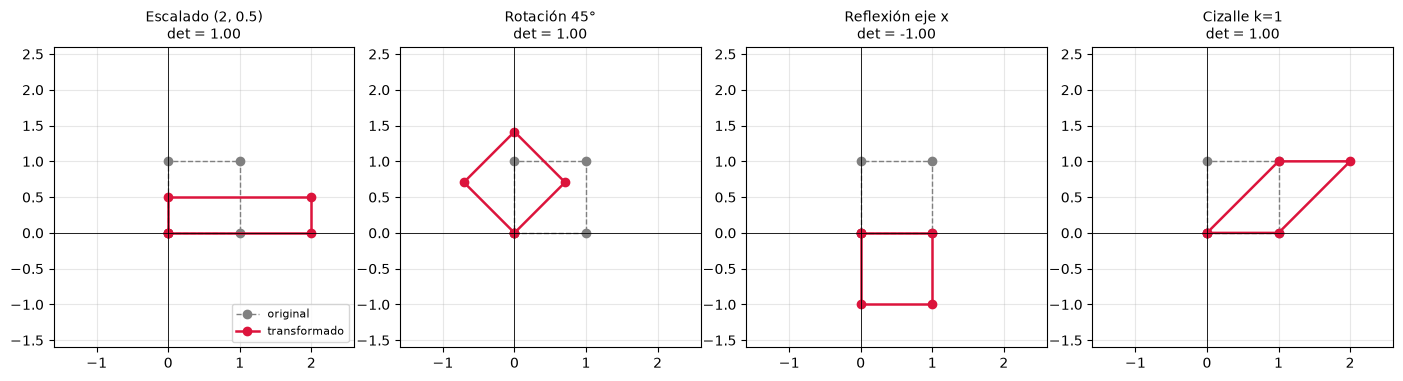

linealidad  M(ax+by) == aMx + bMy : True

M @ x            = [3. 2.]
x1*col1 + x2*col2 = [3. 2.]   (misma cosa)


In [14]:
import numpy as np
import matplotlib.pyplot as plt

# el cuadrado unitario: cada COLUMNA es un punto (x, y)
cuadrado = np.array([[0., 1., 1., 0., 0.],
                     [0., 0., 1., 1., 0.]])

theta = np.pi / 4
transformaciones = {
    "Escalado (2, 0.5)": np.array([[2., 0.], [0., 0.5]]),
    "Rotación 45°":      np.array([[np.cos(theta), -np.sin(theta)],
                                   [np.sin(theta),  np.cos(theta)]]),
    "Reflexión eje x":   np.array([[1., 0.], [0., -1.]]),
    "Cizalle k=1":       np.array([[1., 1.], [0., 1.]]),
}

fig, axes = plt.subplots(1, 4, figsize=(14, 3.6))
for ax, (nombre, M) in zip(axes, transformaciones.items()):
    nuevo = M @ cuadrado                        # transforma todos los puntos de una vez
    ax.plot(cuadrado[0], cuadrado[1], "o--", color="gray", lw=1, label="original")
    ax.plot(nuevo[0], nuevo[1], "o-", color="crimson", lw=1.8, label="transformado")
    ax.set_title(f"{nombre}\ndet = {np.linalg.det(M):.2f}", fontsize=10)
    ax.axhline(0, lw=0.6, color="k"); ax.axvline(0, lw=0.6, color="k")
    ax.set_xlim(-1.6, 2.6); ax.set_ylim(-1.6, 2.6)
    ax.set_aspect("equal"); ax.grid(alpha=0.3)
axes[0].legend(fontsize=8, loc="lower right")
plt.tight_layout()
plt.show()

# --- linealidad y "combinacion lineal de columnas" ---
M = transformaciones["Cizalle k=1"]
x, y = np.array([1., 2.]), np.array([-3., 1.])
a, b = 2.0, 4.0
print(f"linealidad  M(ax+by) == aMx + bMy : {np.allclose(M @ (a * x + b * y), a * (M @ x) + b * (M @ y))}")
print(f"\nM @ x            = {M @ x}")
print(f"x1*col1 + x2*col2 = {x[0] * M[:, 0] + x[1] * M[:, 1]}   (misma cosa)")

### Matrices especiales

| Tipo | Definición | En NumPy |
|---|---|---|
| **Cuadrada** | $m = n$ | `A.shape[0] == A.shape[1]` |
| **Nula** | $a_{ij}=0\;\forall i,j$ | `np.zeros((m, n))` |
| **Identidad** | $I_{ij} = 1$ si $i=j$, $0$ si no | `np.eye(n)` |
| **Diagonal** | $a_{ij}=0$ para $i \neq j$ | `np.diag(v)` |
| **Triangular superior** | $a_{ij}=0$ para $i > j$ | `np.triu(A)` |
| **Triangular inferior** | $a_{ij}=0$ para $i < j$ | `np.tril(A)` |
| **Simétrica** | $A = A^{T}$ | `np.allclose(A, A.T)` |
| **Antisimétrica** | $A = -A^{T}$ (luego $a_{ii}=0$) | `np.allclose(A, -A.T)` |
| **Ortogonal** | $A^{T}A = AA^{T} = I$, luego $A^{-1}=A^{T}$ | `np.allclose(A.T @ A, np.eye(n))` |
| **Definida positiva** | $\mathbf{x}^{T}A\mathbf{x} > 0$ para todo $\mathbf{x}\neq\mathbf{0}$ | todos los *eigenvalues* $> 0$ |

**Hechos útiles:**

- Toda matriz cuadrada se descompone como $A = \underbrace{\tfrac{1}{2}(A+A^{T})}_{\text{simétrica}} + \underbrace{\tfrac{1}{2}(A-A^{T})}_{\text{antisimétrica}}$.
- Para cualquier matriz $A$, el producto $A^{T}A$ es **simétrica** y semidefinida positiva.
- Una matriz ortogonal **preserva normas y ángulos**: $\|A\mathbf{x}\| = \|\mathbf{x}\|$. Las rotaciones son el ejemplo típico.

In [15]:
import numpy as np

np.random.seed(0)
A = np.random.randint(0, 5, size=(3, 3)).astype(float)
print("matriz A:")
print(A)

print("\ntriangular superior np.triu(A):")
print(np.triu(A))
print("\ntriangular inferior np.tril(A):")
print(np.tril(A))
print("\ndiagonal np.diag([1, 2, 3]):")
print(np.diag([1., 2., 3.]))
print(f"\ndiagonal de A: {np.diag(A)}")

# descomposicion simetrica + antisimetrica
S = 0.5 * (A + A.T)
K = 0.5 * (A - A.T)
print("\nparte simetrica S:")
print(S)
print("parte antisimetrica K:")
print(K)
print(f"S simetrica     S == S^T  : {np.allclose(S, S.T)}")
print(f"K antisimetrica K == -K^T : {np.allclose(K, -K.T)}")
print(f"A == S + K                : {np.allclose(A, S + K)}")

# A^T A siempre es simetrica y semidefinida positiva
G = A.T @ A
print(f"\nA^T A simetrica            : {np.allclose(G, G.T)}")
print(f"eigenvalues de A^T A >= 0  : {np.round(np.linalg.eigvalsh(G), 4)}")

# matriz ortogonal: una rotacion
theta = np.radians(30)
R = np.array([[np.cos(theta), -np.sin(theta)],
              [np.sin(theta),  np.cos(theta)]])
x = np.array([3., 4.])
print(f"\nR^T R == I          : {np.allclose(R.T @ R, np.eye(2))}")
print(f"R^-1 == R^T         : {np.allclose(np.linalg.inv(R), R.T)}")
print(f"|det(R)| == 1       : {np.isclose(abs(np.linalg.det(R)), 1.0)}")
print(f"||Rx|| == ||x||     : {np.linalg.norm(R @ x):.4f} == {np.linalg.norm(x):.4f}  (preserva la norma)")

matriz A:
[[4. 0. 3.]
 [3. 3. 1.]
 [3. 2. 4.]]

triangular superior np.triu(A):
[[4. 0. 3.]
 [0. 3. 1.]
 [0. 0. 4.]]

triangular inferior np.tril(A):
[[4. 0. 0.]
 [3. 3. 0.]
 [3. 2. 4.]]

diagonal np.diag([1, 2, 3]):
[[1. 0. 0.]
 [0. 2. 0.]
 [0. 0. 3.]]

diagonal de A: [4. 3. 4.]

parte simetrica S:
[[4.  1.5 3. ]
 [1.5 3.  1.5]
 [3.  1.5 4. ]]
parte antisimetrica K:
[[ 0.  -1.5  0. ]
 [ 1.5  0.  -0.5]
 [ 0.   0.5  0. ]]
S simetrica     S == S^T  : True
K antisimetrica K == -K^T : True
A == S + K                : True

A^T A simetrica            : True
eigenvalues de A^T A >= 0  : [ 2.2281  6.7355 64.0365]

R^T R == I          : True
R^-1 == R^T         : True
|det(R)| == 1       : True
||Rx|| == ||x||     : 5.0000 == 5.0000  (preserva la norma)


### Determinante, traza, rango e inversa

**Determinante** $\det(A)$ — sólo para matrices **cuadradas**. Mide el factor de cambio de área/volumen de la transformación:

$$
\det\begin{bmatrix} a & b \\ c & d\end{bmatrix} = ad - bc
\qquad\qquad
\det(A) = \sum_{j=1}^{n} (-1)^{1+j} a_{1j}\,\det(A_{1j}) \;\;(\text{expansión por cofactores})
$$

**Traza** $\operatorname{tr}(A) = \sum_{i=1}^{n} a_{ii}$ — la suma de la diagonal.

**Rango** $\operatorname{rank}(A)$ — número de filas (o columnas) linealmente independientes; siempre $\operatorname{rank}(A) \le \min(m,n)$.

**Inversa** $A^{-1}$ — la única matriz tal que $AA^{-1} = A^{-1}A = I$. Para el caso $2\times 2$:

$$
A^{-1} = \frac{1}{ad-bc}\begin{bmatrix} d & -b \\ -c & a \end{bmatrix}
$$

**Propiedades:**

| Determinante | Traza | Inversa |
|---|---|---|
| $\det(A^{T}) = \det(A)$ | $\operatorname{tr}(A+B) = \operatorname{tr}(A)+\operatorname{tr}(B)$ | $(A^{-1})^{-1} = A$ |
| $\det(AB) = \det(A)\det(B)$ | $\operatorname{tr}(\alpha A) = \alpha \operatorname{tr}(A)$ | $(AB)^{-1} = B^{-1}A^{-1}$ ⚠️ |
| $\det(\alpha A) = \alpha^{n}\det(A)$ | $\operatorname{tr}(AB) = \operatorname{tr}(BA)$ | $(A^{T})^{-1} = (A^{-1})^{T}$ |
| $\det(A^{-1}) = 1/\det(A)$ | $\operatorname{tr}(A) = \sum_i \lambda_i$ | $(\alpha A)^{-1} = \alpha^{-1}A^{-1}$ |
| $\det(A) = \prod_i \lambda_i$ | | |

> 🔑 **Teorema fundamental.** Para $A \in \mathbb{R}^{n\times n}$ son equivalentes:
> $A$ es invertible $\iff \det(A) \neq 0 \iff \operatorname{rank}(A) = n \iff A\mathbf{x}=\mathbf{0}$ sólo tiene la solución trivial $\iff$ ningún *eigenvalue* es $0$.
>
> Si $\det(A) = 0$ la matriz es **singular**: colapsa el espacio a una dimensión menor y la transformación no se puede deshacer.

In [16]:
import numpy as np

A = np.array([[4., 7.], [2., 6.]])
B = np.array([[1., 2.], [3., 5.]])
alpha, n = 3.0, 2

print("A ="); print(A)
print(f"\ndet(A) = {np.linalg.det(A):.4f}   (a*d - b*c = 4*6 - 7*2 = {4*6 - 7*2})")
print(f"tr(A)  = {np.trace(A):.4f}")
print(f"rank(A) = {np.linalg.matrix_rank(A)}")
print("\ninversa A^-1 =")
print(np.linalg.inv(A))
print("\nformula 2x2: (1/det) [[d, -b], [-c, a]] =")
print(1 / np.linalg.det(A) * np.array([[A[1, 1], -A[0, 1]], [-A[1, 0], A[0, 0]]]))
print(f"\nA @ A^-1 == I : {np.allclose(A @ np.linalg.inv(A), np.eye(2))}")

print("\n--- propiedades del determinante ---")
print(f"det(A^T) == det(A)          : {np.isclose(np.linalg.det(A.T), np.linalg.det(A))}")
print(f"det(AB) == det(A)det(B)     : {np.isclose(np.linalg.det(A @ B), np.linalg.det(A) * np.linalg.det(B))}")
print(f"det(aA) == a^n det(A)       : {np.isclose(np.linalg.det(alpha * A), alpha**n * np.linalg.det(A))}")
print(f"det(A^-1) == 1/det(A)       : {np.isclose(np.linalg.det(np.linalg.inv(A)), 1 / np.linalg.det(A))}")
print(f"det(A) == prod(eigenvalues) : {np.isclose(np.linalg.det(A), np.prod(np.linalg.eigvals(A)))}")

print("\n--- propiedades de la traza ---")
print(f"tr(A+B) == tr(A)+tr(B)      : {np.isclose(np.trace(A + B), np.trace(A) + np.trace(B))}")
print(f"tr(AB) == tr(BA)            : {np.isclose(np.trace(A @ B), np.trace(B @ A))}")
print(f"tr(A) == suma(eigenvalues)  : {np.isclose(np.trace(A), np.sum(np.linalg.eigvals(A)).real)}")

print("\n--- propiedades de la inversa ---")
print(f"(A^-1)^-1 == A              : {np.allclose(np.linalg.inv(np.linalg.inv(A)), A)}")
print(f"(AB)^-1 == B^-1 A^-1        : {np.allclose(np.linalg.inv(A @ B), np.linalg.inv(B) @ np.linalg.inv(A))}")
print(f"(AB)^-1 == A^-1 B^-1 ?      : {np.allclose(np.linalg.inv(A @ B), np.linalg.inv(A) @ np.linalg.inv(B))}  <- ojo!")
print(f"(A^T)^-1 == (A^-1)^T        : {np.allclose(np.linalg.inv(A.T), np.linalg.inv(A).T)}")

A =
[[4. 7.]
 [2. 6.]]

det(A) = 10.0000   (a*d - b*c = 4*6 - 7*2 = 10)
tr(A)  = 10.0000
rank(A) = 2

inversa A^-1 =
[[ 0.6 -0.7]
 [-0.2  0.4]]

formula 2x2: (1/det) [[d, -b], [-c, a]] =
[[ 0.6 -0.7]
 [-0.2  0.4]]

A @ A^-1 == I : True

--- propiedades del determinante ---
det(A^T) == det(A)          : True
det(AB) == det(A)det(B)     : True
det(aA) == a^n det(A)       : True
det(A^-1) == 1/det(A)       : True
det(A) == prod(eigenvalues) : True

--- propiedades de la traza ---
tr(A+B) == tr(A)+tr(B)      : True
tr(AB) == tr(BA)            : True
tr(A) == suma(eigenvalues)  : True

--- propiedades de la inversa ---
(A^-1)^-1 == A              : True
(AB)^-1 == B^-1 A^-1        : True
(AB)^-1 == A^-1 B^-1 ?      : False  <- ojo!
(A^T)^-1 == (A^-1)^T        : True


In [17]:
import numpy as np

# --- matriz SINGULAR: la fila 2 es el doble de la fila 1 ---
S = np.array([[1., 2., 3.],
              [2., 4., 6.],
              [1., 1., 1.]])

print("matriz S (fila 2 = 2 x fila 1):")
print(S)
print(f"\ndet(S)   = {np.linalg.det(S):.10f}   -> practicamente 0")
print(f"rank(S)  = {np.linalg.matrix_rank(S)}   de un maximo de {min(S.shape)}  -> deficiente en rango")

try:
    np.linalg.inv(S)
except np.linalg.LinAlgError as e:
    print(f"\nnp.linalg.inv(S) falla: {e}")

# el sistema homogeneo Sx = 0 tiene soluciones no triviales
print("\n--- comparacion de rangos ---")
for nombre, M in {
    "identidad 3x3": np.eye(3),
    "singular S": S,
    "matriz 3x5 aleatoria": np.random.default_rng(7).normal(size=(3, 5)),
    "producto columna x fila": np.outer([1., 2., 3.], [4., 5., 6.]),
}.items():
    print(f"{nombre:<25} shape={str(M.shape):<8} rank={np.linalg.matrix_rank(M)}")

matriz S (fila 2 = 2 x fila 1):
[[1. 2. 3.]
 [2. 4. 6.]
 [1. 1. 1.]]

det(S)   = 0.0000000000   -> practicamente 0
rank(S)  = 2   de un maximo de 3  -> deficiente en rango

np.linalg.inv(S) falla: Singular matrix

--- comparacion de rangos ---
identidad 3x3             shape=(3, 3)   rank=3
singular S                shape=(3, 3)   rank=2
matriz 3x5 aleatoria      shape=(3, 5)   rank=3
producto columna x fila   shape=(3, 3)   rank=1


## Operaciones

### Aritméticas (element-wise)


### Operaciones aritméticas


In [18]:
a = np.array([1, 2, 3])
b = np.array([4, 5, 6])

print(a + b)   # [5 7 9]
print(a - b)   # [-3 -3 -3]
print(a * b)   # [4 10 18]
print(a / b)   # [0.25 0.4  0.5]
print(a ** 2)  # [1 4 9]

[5 7 9]
[-3 -3 -3]
[ 4 10 18]
[0.25 0.4  0.5 ]
[1 4 9]


> - `a * b` es multiplicación **elemento a elemento**, no producto matricial.
> - Para producto matricial usa `np.dot(A, B)` o el operador `@`.

### Comparación

In [19]:
a = np.array([1, 2, 3])
b = np.array([2, 2, 4])

print(a == b)   # [False  True False]
print(a > b)    # [False False False]
print(a <= b)   # [ True  True  True]

[False  True False]
[False False False]
[ True  True  True]



Los resultados son arrays booleanos — útiles para **filtrar** datos:

In [20]:
# Seleccionar elementos mayores a 2
print(a[a > 2])   # [3]

[3]


### Estadísticas

In [21]:
a = np.array([2, 4, 4, 4, 5, 5, 7, 9])

print(f"suma:    {np.sum(a)}")
print(f"media:   {np.mean(a):.2f}")
print(f"std:     {np.std(a):.2f}")
print(f"mínimo:  {np.min(a)}")
print(f"máximo:  {np.max(a)}")
print(f"mediana: {np.median(a)}")

suma:    40
media:   5.00
std:     2.00
mínimo:  2
máximo:  9
mediana: 4.5


## Indexación y Slicing 



In [22]:
# --- 1D ---
a = np.array([10, 20, 30, 40, 50])

print("\n--- vector 1D ---")
print(a)

print("\nprimer elemento (a[0]):")
print(a[0])

print("\núltimo elemento (a[-1]):")
print(a[-1])

print("\nslice a[1:4]:")
print(a[1:4])

print("\ncada dos elementos a[::2]:")
print(a[::2])

# --- 2D ---
M = np.array([
    [1, 2, 3],
    [4, 5, 6],
    [7, 8, 9]
])

print("\n--- matriz 2D ---")
print(M)

print("\nprimera fila M[0, :]:")
print(M[0, :])

print("\nsegunda columna M[:, 1]:")
print(M[:, 1])

print("\nelemento (fila 1, col 2) M[1, 2]:")
print(M[1, 2])

print("\nprimeras dos filas M[:2, :]:")
print(M[:2, :])

print("\ndiagonal M.diagonal():")
print(M.diagonal())


--- vector 1D ---
[10 20 30 40 50]

primer elemento (a[0]):
10

último elemento (a[-1]):
50

slice a[1:4]:
[20 30 40]

cada dos elementos a[::2]:
[10 30 50]

--- matriz 2D ---
[[1 2 3]
 [4 5 6]
 [7 8 9]]

primera fila M[0, :]:
[1 2 3]

segunda columna M[:, 1]:
[2 5 8]

elemento (fila 1, col 2) M[1, 2]:
6

primeras dos filas M[:2, :]:
[[1 2 3]
 [4 5 6]]

diagonal M.diagonal():
[1 5 9]


## Algebra Lineal

NumPy cubre las operaciones fundamentales del curso vía `np.linalg`:

### Eigenvalues, eigenvectors y descomposiciones

Un **eigenvector** (vector propio) $\mathbf{v}\neq\mathbf{0}$ de una matriz cuadrada $A$ es una dirección que la transformación **no cambia**, sólo estira o contrae por un factor $\lambda$ (el **eigenvalue** o valor propio):

$$
A\mathbf{v} = \lambda\,\mathbf{v}
\qquad\Longleftrightarrow\qquad
(A - \lambda I)\mathbf{v} = \mathbf{0}
\qquad\Longrightarrow\qquad
\underbrace{\det(A - \lambda I) = 0}_{\text{polinomio característico}}
$$

Se cumple siempre que $\operatorname{tr}(A) = \sum_i \lambda_i$ y $\det(A) = \prod_i \lambda_i$.

La **descomposición en valores singulares (SVD)** existe para **cualquier** matriz $A \in \mathbb{R}^{m\times n}$:

$$
A = U\,\Sigma\,V^{T}, \qquad U^{T}U = I_m,\;\; V^{T}V = I_n,\;\; \Sigma = \operatorname{diag}(\sigma_1 \ge \sigma_2 \ge \cdots \ge 0)
$$

donde los **valores singulares** $\sigma_i$ son las raíces de los eigenvalues de $A^{T}A$. El rango de $A$ es el número de $\sigma_i$ no nulos. Es la base de PCA, compresión de imágenes y sistemas de recomendación.

Finalmente, un **sistema de ecuaciones lineales** se escribe como $A\mathbf{x} = \mathbf{b}$ y, si $A$ es invertible, tiene la solución única $\mathbf{x} = A^{-1}\mathbf{b}$.

> ⚠️ En la práctica **nunca** se calcula `inv(A) @ b`: se usa `np.linalg.solve(A, b)`, que es más rápido y numéricamente más estable.

NumPy cubre todas estas operaciones vía `np.linalg`:

In [23]:
import numpy as np

A = np.array([[1, 2],
              [3, 4]])

# --- operaciones básicas ---
print("matriz A:")
print(A)

print("\ntranspuesta A.T:")
print(A.T)

print("\ndeterminante:")
print(round(np.linalg.det(A), 4))

print("\ninversa:")
print(np.linalg.inv(A))

print("\ntraza:")
print(np.trace(A))

# --- valores y vectores propios ---
print("\n--- eigendescomposición ---")
vals, vecs = np.linalg.eig(A)
print(f"eigenvalues:  {np.round(vals, 4)}")
print(f"eigenvectors:\n{np.round(vecs, 4)}")

# --- normas ---
print("\n--- normas ---")
print(f"norma frobenius:  {np.linalg.norm(A, 'fro'):.4f}")
print(f"norma espectral:  {np.linalg.norm(A, 2):.4f}")
print(f"rango:            {np.linalg.matrix_rank(A)}")

# --- descomposiciones ---
print("\n--- descomposición SVD ---")
U, S, Vt = np.linalg.svd(A)
print(f"U:\n{np.round(U, 4)}")
print(f"valores singulares: {np.round(S, 4)}")
print(f"Vt:\n{np.round(Vt, 4)}")

# --- sistema de ecuaciones Ax = b ---
print("\n--- sistema Ax = b ---")
b = np.array([5., 7.])
x = np.linalg.solve(A, b)
print(f"b:          {b}")
print(f"solución x: {np.round(x, 4)}")
print(f"verificación Ax: {np.round(A @ x, 4)}")

matriz A:
[[1 2]
 [3 4]]

transpuesta A.T:
[[1 3]
 [2 4]]

determinante:
-2.0

inversa:
[[-2.   1. ]
 [ 1.5 -0.5]]

traza:
5

--- eigendescomposición ---
eigenvalues:  [-0.3723+0.j  5.3723+0.j]
eigenvectors:
[[-0.8246+0.j -0.416 +0.j]
 [ 0.5658+0.j -0.9094+0.j]]

--- normas ---
norma frobenius:  5.4772
norma espectral:  5.4650
rango:            2

--- descomposición SVD ---
U:
[[-0.4046 -0.9145]
 [-0.9145  0.4046]]
valores singulares: [5.465 0.366]
Vt:
[[-0.576  -0.8174]
 [ 0.8174 -0.576 ]]

--- sistema Ax = b ---
b:          [5. 7.]
solución x: [-3.  4.]
verificación Ax: [5. 7.]


#### Ejemplo: sistema de ecuaciones $3\times 3$

$$
\begin{cases}
2x + \;\;y - \;\;z = 8 \\
-3x - \;\;y + 2z = -11 \\
-2x + y + 2z = -3
\end{cases}
\qquad\Longleftrightarrow\qquad
\underbrace{\begin{bmatrix} 2 & 1 & -1 \\ -3 & -1 & 2 \\ -2 & 1 & 2 \end{bmatrix}}_{A}
\underbrace{\begin{bmatrix} x \\ y \\ z \end{bmatrix}}_{\mathbf{x}}
=
\underbrace{\begin{bmatrix} 8 \\ -11 \\ -3\end{bmatrix}}_{\mathbf{b}}
$$

In [24]:
import numpy as np

A = np.array([[ 2.,  1., -1.],
              [-3., -1.,  2.],
              [-2.,  1.,  2.]])
b = np.array([8., -11., -3.])

print(f"det(A) = {np.linalg.det(A):.4f}  -> distinto de 0, existe solucion unica")

x = np.linalg.solve(A, b)
print(f"\nsolucion x = {np.round(x, 6)}   (x=2, y=3, z=-1)")
print(f"verificacion A @ x = {np.round(A @ x, 6)}  == b = {b}")

# comparacion con la inversa (correcto, pero menos estable y mas lento)
print(f"\nA^-1 @ b   = {np.round(np.linalg.inv(A) @ b, 6)}")
print(f"numero de condicion cond(A) = {np.linalg.cond(A):.4f}  (mientras mayor, peor condicionado)")

# eigenvalues: verificacion de traza y determinante
vals, vecs = np.linalg.eig(A)
print(f"\neigenvalues: {np.round(vals, 4)}")
print(f"suma eigenvalues = {np.sum(vals).real:.4f}   ==  tr(A) = {np.trace(A):.4f}")
print(f"prod eigenvalues = {np.prod(vals).real:.4f}   ==  det(A) = {np.linalg.det(A):.4f}")

# Av = lambda v para el primer par propio
lam, v0 = vals[0].real, vecs[:, 0].real
print(f"\nA @ v0     = {np.round(A @ v0, 6)}")
print(f"lambda * v0 = {np.round(lam * v0, 6)}   -> se cumple A v = lambda v")

det(A) = -1.0000  -> distinto de 0, existe solucion unica

solucion x = [ 2.  3. -1.]   (x=2, y=3, z=-1)
verificacion A @ x = [  8. -11.  -3.]  == b = [  8. -11.  -3.]

A^-1 @ b   = [ 2.  3. -1.]
numero de condicion cond(A) = 44.6723  (mientras mayor, peor condicionado)

eigenvalues: [ 3.2143+0.j  0.4608+0.j -0.6751+0.j]
suma eigenvalues = 3.0000   ==  tr(A) = 3.0000
prod eigenvalues = -1.0000   ==  det(A) = -1.0000

A @ v0     = [-0.710803  1.742608  2.605749]
lambda * v0 = [-0.710803  1.742608  2.605749]   -> se cumple A v = lambda v


#### Ejemplo: mínimos cuadrados (regresión lineal)

Cuando el sistema $A\mathbf{x}=\mathbf{b}$ tiene **más ecuaciones que incógnitas** normalmente no tiene solución exacta. Se busca entonces la $\hat{\mathbf{x}}$ que minimiza el error cuadrático, cuya solución son las **ecuaciones normales**:

$$
\hat{\mathbf{x}} = \arg\min_{\mathbf{x}} \|A\mathbf{x} - \mathbf{b}\|_2^{2}
\qquad\Longrightarrow\qquad
A^{T}A\,\hat{\mathbf{x}} = A^{T}\mathbf{b}
\qquad\Longrightarrow\qquad
\hat{\mathbf{x}} = (A^{T}A)^{-1}A^{T}\mathbf{b}
$$

Geométricamente, $A\hat{\mathbf{x}}$ es la **proyección ortogonal** de $\mathbf{b}$ sobre el espacio generado por las columnas de $A$ — la misma idea de proyección vista en la sección de vectores.

In [25]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)
x = np.linspace(0, 10, 25)
y = 2.5 * x + 1.0 + rng.normal(0, 2.0, size=x.size)   # recta real: y = 2.5x + 1

# matriz de diseno: columna de x y columna de unos (intercepto)
A = np.column_stack([x, np.ones_like(x)])
print(f"A tiene shape {A.shape}: {A.shape[0]} ecuaciones y {A.shape[1]} incognitas (sobredeterminado)")

# 1) ecuaciones normales, "a mano"
coef_normal = np.linalg.inv(A.T @ A) @ A.T @ y

# 2) la forma recomendada
coef_lstsq, residuos, rank, sv = np.linalg.lstsq(A, y, rcond=None)

print(f"\npendiente e intercepto (ecuaciones normales) : {np.round(coef_normal, 4)}")
print(f"pendiente e intercepto (np.linalg.lstsq)     : {np.round(coef_lstsq, 4)}")
print(f"valores reales                               : [2.5 1.0]")
print(f"\nerror ||Ax - b||_2 = {np.linalg.norm(A @ coef_lstsq - y):.4f}")
print(f"residuo ortogonal a las columnas de A: {np.round(A.T @ (y - A @ coef_lstsq), 8)}")

plt.figure(figsize=(6, 4))
plt.scatter(x, y, color="steelblue", label="datos observados")
plt.plot(x, A @ coef_lstsq, color="crimson", lw=2,
         label=f"ajuste: y = {coef_lstsq[0]:.2f}x + {coef_lstsq[1]:.2f}")
plt.title("Mínimos cuadrados como proyección ortogonal")
plt.xlabel("x"); plt.ylabel("y")
plt.grid(alpha=0.3); plt.legend()
plt.tight_layout()
plt.show()

A tiene shape (25, 2): 25 ecuaciones y 2 incognitas (sobredeterminado)

pendiente e intercepto (ecuaciones normales) : [2.5602 0.6282]
pendiente e intercepto (np.linalg.lstsq)     : [2.5602 0.6282]
valores reales                               : [2.5 1.0]

error ||Ax - b||_2 = 8.0926
residuo ortogonal a las columnas de A: [-0. -0.]


#### Ejemplo: SVD y aproximación de rango bajo

La SVD permite escribir $A$ como suma de matrices de rango 1, ordenadas por importancia:

$$
A = \sum_{i=1}^{r} \sigma_i\, \mathbf{u}_i \mathbf{v}_i^{T}
$$

Quedarse con los primeros $k$ términos da la **mejor aproximación de rango $k$** posible (teorema de Eckart–Young) — la idea detrás de PCA y de la compresión de datos.

In [26]:
import numpy as np

rng = np.random.default_rng(0)
A = rng.normal(size=(6, 4))

U, S, Vt = np.linalg.svd(A, full_matrices=False)
print(f"U: {U.shape}   S: {S.shape}   Vt: {Vt.shape}")
print(f"valores singulares: {np.round(S, 4)}")
print(f"rank(A) = {np.linalg.matrix_rank(A)} = numero de sigma_i > 0")

print(f"\nreconstruccion A == U S V^T : {np.allclose(A, U @ np.diag(S) @ Vt)}")
print(f"U ortogonal por columnas    : {np.allclose(U.T @ U, np.eye(U.shape[1]))}")
print(f"sigma_1 == norma espectral  : {np.isclose(S[0], np.linalg.norm(A, 2))}")
print(f"||A||_F == sqrt(sum sigma^2): {np.isclose(np.linalg.norm(A, 'fro'), np.sqrt(np.sum(S**2)))}")

# aproximaciones de rango k
print("\n--- aproximacion de rango bajo ---")
for k in range(1, len(S) + 1):
    Ak = U[:, :k] @ np.diag(S[:k]) @ Vt[:k, :]
    error = np.linalg.norm(A - Ak, "fro") / np.linalg.norm(A, "fro")
    print(f"k={k}  rank(Ak)={np.linalg.matrix_rank(Ak)}  error relativo = {error:.4%}")

U: (6, 4)   S: (4,)   Vt: (4, 4)
valores singulares: [3.0361 2.0335 1.8563 0.8954]
rank(A) = 4 = numero de sigma_i > 0

reconstruccion A == U S V^T : True
U ortogonal por columnas    : True
sigma_1 == norma espectral  : True
||A||_F == sqrt(sum sigma^2): True

--- aproximacion de rango bajo ---
k=1  rank(Ak)=1  error relativo = 69.0134%
k=2  rank(Ak)=2  error relativo = 49.1258%
k=3  rank(Ak)=3  error relativo = 21.3422%
k=4  rank(Ak)=4  error relativo = 0.0000%


## Broadcasting

Broadcasting permite operar entre arrays de **distinta forma** sin copiar datos.
La regla básica: NumPy "expande" el array más pequeño para que las formas sean compatibles.

<img src="https://raw.githubusercontent.com/fralfaro/MAT281_2022/main/docs/lectures/data_manipulation/scientific_computing/images/broad.png" width = "500" align="center"/>



In [27]:
import numpy as np

# --- escalar + vector ---
print("escalar + vector (np.arange(3) + 5):")
print(np.arange(3) + 5)

print("\nescalar * vector (np.arange(3) * 3):")
print(np.arange(3) * 3)

# --- matriz + vector (broadcasting por filas) ---
print("\n--- broadcasting por filas ---")
print("matriz ones(3,3) + arange(3):")
print(np.ones((3, 3)) + np.arange(3))

print("\nmatriz ones(3,3) * arange(3):")
print(np.ones((3, 3)) * np.arange(3))

# --- vector columna + vector fila → matriz ---
print("\n--- vector columna + vector fila ---")
col = np.arange(3).reshape((3, 1))
fil = np.arange(3)
print("columna:")
print(col)
print("\nfila:")
print(fil)
print("\nresultado col + fila:")
print(col + fil)

# --- comparaciones con broadcasting ---
print("\n--- comparaciones ---")
M = np.arange(9).reshape((3, 3))
print("matriz M:")
print(M)
print("\nM > 4:")
print(M > 4)
print("\nM[M > 4]  (filtrado):")
print(M[M > 4])

# --- operaciones entre matrices compatibles ---
print("\n--- shapes compatibles ---")
A = np.ones((3, 3)) * 10
b = np.array([1, 2, 3])
print("A (3x3):")
print(A)
print("\nb (3,):")
print(b)
print("\nA / b:")
print(A / b)

escalar + vector (np.arange(3) + 5):
[5 6 7]

escalar * vector (np.arange(3) * 3):
[0 3 6]

--- broadcasting por filas ---
matriz ones(3,3) + arange(3):
[[1. 2. 3.]
 [1. 2. 3.]
 [1. 2. 3.]]

matriz ones(3,3) * arange(3):
[[0. 1. 2.]
 [0. 1. 2.]
 [0. 1. 2.]]

--- vector columna + vector fila ---
columna:
[[0]
 [1]
 [2]]

fila:
[0 1 2]

resultado col + fila:
[[0 1 2]
 [1 2 3]
 [2 3 4]]

--- comparaciones ---
matriz M:
[[0 1 2]
 [3 4 5]
 [6 7 8]]

M > 4:
[[False False False]
 [False False  True]
 [ True  True  True]]

M[M > 4]  (filtrado):
[5 6 7 8]

--- shapes compatibles ---
A (3x3):
[[10. 10. 10.]
 [10. 10. 10.]
 [10. 10. 10.]]

b (3,):
[1 2 3]

A / b:
[[10.          5.          3.33333333]
 [10.          5.          3.33333333]
 [10.          5.          3.33333333]]


## Resumen: notación matemática ↔ NumPy

| Concepto | Notación | NumPy |
|---|---|---|
| Vector de $\mathbb{R}^n$ | $\mathbf{v}$ | `np.array([...])`, `shape=(n,)` |
| Matriz $m\times n$ | $A$ | `np.array([[...]])`, `shape=(m, n)` |
| Elemento | $a_{ij}$ | `A[i-1, j-1]` |
| Suma | $A + B$ | `A + B` |
| Producto por escalar | $\alpha A$ | `alpha * A` |
| Producto **elemento a elemento** | $A \odot B$ | `A * B` |
| Producto **punto** | $\mathbf{u}\cdot\mathbf{v} = \mathbf{u}^T\mathbf{v}$ | `u @ v`, `np.dot(u, v)` |
| Producto **matricial** | $AB$ | `A @ B`, `np.matmul(A, B)` |
| Transpuesta | $A^{T}$ | `A.T` |
| Norma euclidiana | $\|\mathbf{v}\|_2$ | `np.linalg.norm(v)` |
| Identidad | $I_n$ | `np.eye(n)` |
| Diagonal | $\operatorname{diag}(\mathbf{v})$ | `np.diag(v)` |
| Traza | $\operatorname{tr}(A)$ | `np.trace(A)` |
| Determinante | $\det(A)$ | `np.linalg.det(A)` |
| Rango | $\operatorname{rank}(A)$ | `np.linalg.matrix_rank(A)` |
| Inversa | $A^{-1}$ | `np.linalg.inv(A)` |
| Sistema lineal | $A\mathbf{x}=\mathbf{b}$ | `np.linalg.solve(A, b)` |
| Mínimos cuadrados | $\min\|A\mathbf{x}-\mathbf{b}\|^2$ | `np.linalg.lstsq(A, b)` |
| Eigenvalues / eigenvectors | $A\mathbf{v}=\lambda\mathbf{v}$ | `np.linalg.eig(A)` |
| SVD | $A = U\Sigma V^{T}$ | `np.linalg.svd(A)` |

**Errores frecuentes:**

1. Confundir `A * B` (elemento a elemento) con `A @ B` (producto matricial).
2. Asumir que $AB = BA$ — el producto matricial **no es conmutativo**.
3. Escribir $(AB)^{-1} = A^{-1}B^{-1}$ o $(AB)^{T} = A^{T}B^{T}$ — en ambos casos **el orden se invierte**.
4. Usar `inv(A) @ b` en vez de `solve(A, b)` para resolver sistemas.
5. Olvidar que un vector 1D de NumPy (`shape=(n,)`) no es fila ni columna.

## Referencias

1. [Quickstart tutorial-numpy](https://docs.scipy.org/doc/numpy/user/quickstart.html)
